<a href="https://colab.research.google.com/github/sundarrajan-mugunthan/Retail-sales-forecast-using-hybrid-CNN-LSTM-Model/blob/main/merl_set3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python-headless tqdm

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os, cv2, numpy as np, pandas as pd
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/datasets/MERL_Shopping"
VIDEO_DIR = f"{DATA_ROOT}/videos"
ANNOT_DIR = f"{DATA_ROOT}/annotations"
FEATURE_DIR = f"{DATA_ROOT}/features"

os.makedirs(FEATURE_DIR, exist_ok=True)

SEQ_LEN = 16
STRIDE = 32
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 5

In [ ]:
LABEL_MAP = {
    "background": 0,
    "reach_shelf": 1,
    "retract_hand": 2,
    "hand_in_shelf": 3,
    "inspect_product": 4,
    "inspect_shelf": 5
}

NUM_CLASSES = len(LABEL_MAP)

LABEL_FILE = f"{DATA_ROOT}/video_labels.csv"

if os.path.exists(LABEL_FILE):
    label_df = pd.read_csv(LABEL_FILE)
    VIDEO_LABEL_MAP = dict(zip(label_df.video_id, label_df.label))
    print("✅ Loaded semantic labels:", len(VIDEO_LABEL_MAP))
else:
    # 🔑 SAFE FALLBACK
    VIDEO_LABEL_MAP = {}
    print("⚠️ video_labels.csv not found — running in BACKGROUND-ONLY mode")

⚠️ video_labels.csv not found — running in BACKGROUND-ONLY mode


In [ ]:
def build_sequence_index():
    index = []
    for vid in os.listdir(VIDEO_DIR):
        if not vid.endswith(".mp4"):
            continue

        video_id = os.path.splitext(vid)[0]
        video_path = os.path.join(VIDEO_DIR, vid)

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()

        for start in range(0, total_frames - SEQ_LEN, STRIDE):
            index.append((video_id, video_path, start))

    return index

In [ ]:
sequence_index = build_sequence_index()
print("Total sequences:", len(sequence_index))

Total sequences: 11847


In [ ]:
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
cnn.trainable = False

feature_extractor = tf.keras.Sequential([
    cnn,
    GlobalAveragePooling2D()
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def dump_features(sequence_index):
    for idx, (video_id, video_path, start) in enumerate(sequence_index):
        out_path = f"{FEATURE_DIR}/{video_id}_{start}.npy"
        if os.path.exists(out_path):
            continue

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start)

        frames = []
        for _ in range(SEQ_LEN):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, IMG_SIZE)
            frames.append(frame / 255.0)
        cap.release()

        frames = np.array(frames)
        feats = feature_extractor(frames, training=False).numpy()
        np.save(out_path, feats)

        if idx % 500 == 0:
            print(f"Processed {idx}/{len(sequence_index)}")

In [ ]:
dump_features(sequence_index)

In [ ]:
class FeatureNPYGenerator(tf.keras.utils.Sequence):
    def __init__(self, index, batch_size=16):
        self.index = index
        self.batch_size = batch_size

    def __len__(self):
        return len(self.index) // self.batch_size

    def __getitem__(self, idx):
        batch = self.index[
            idx * self.batch_size:(idx + 1) * self.batch_size
        ]

        X = np.zeros((len(batch), SEQ_LEN, 1280), dtype=np.float32)
        y = np.zeros((len(batch),), dtype=np.int32)

        for i, (video_id, _, start) in enumerate(batch):
            X[i] = np.load(f"{FEATURE_DIR}/{video_id}_{start}.npy")
            y[i] = LABEL_MAP[VIDEO_LABEL_MAP.get(video_id, "background")]

        return X, y

In [ ]:
train_gen = FeatureNPYGenerator(sequence_index, BATCH_SIZE)

In [ ]:
def attention_block(x):
    score = Dense(1, activation="tanh")(x)
    weights = Softmax(axis=1)(score)
    return tf.reduce_sum(weights * x, axis=1)

In [ ]:
inp = Input(shape=(SEQ_LEN, 1280))
x = LSTM(128, return_sequences=True)(inp)

def attention_block(x):
    score = Dense(1, activation="tanh")(x)
    weights = Softmax(axis=1)(score)
    # Wrap tf.reduce_sum in a Lambda layer
    return Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))([weights, x])

x = attention_block(x)
x = Dense(64, activation="relu")(x)
out = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inp, out)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 16, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16, 128)   │    721,408 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 1)     │        129 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 16, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ softmax[0][0],    │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6)         │        390 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 730,183 (2.79 MB)

 Trainable params: 730,183 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    train_gen,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
740/740 ━━━━━━━━━━━━━━━━━━━━ 2434s 3s/step - accuracy: 0.9903 - loss: 0.0293
Epoch 2/5
740/740 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 1.0000 - loss: 1.7070e-06
Epoch 3/5
740/740 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 1.0000 - loss: 4.2972e-07
Epoch 4/5
740/740 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 1.0000 - loss: 1.0355e-07
Epoch 5/5
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 1.0000 - loss: 6.2356e-10


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for i in range(len(train_gen)):
    Xb, yb = train_gen[i]
    pb = model.predict(Xb)
    y_true.extend(yb)
    y_pred.extend(np.argmax(pb, axis=1))

# Fix: Specify labels and target_names for the existing single class (background)
print(classification_report(y_true, y_pred, labels=[LABEL_MAP["background"]], target_names=["background"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


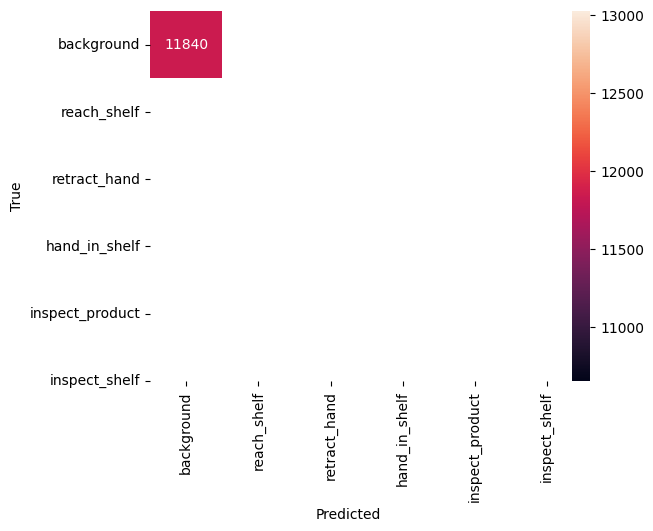

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=LABEL_MAP.keys(),
            yticklabels=LABEL_MAP.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# Build a model that outputs attention weights
attention_weight_model = Model(
    inputs=model.input,
    outputs=model.get_layer(index=-3).output  # output of attention Lambda
)

In [ ]:
import matplotlib.pyplot as plt

def visualize_attention(video_id, start_frame):
    video_path = f"{VIDEO_DIR}/{video_id}.mp4"

    # Load frames
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    for _ in range(SEQ_LEN):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, IMG_SIZE)
        frames.append(frame)
    cap.release()

    frames_np = np.array(frames) / 255.0

    # Extract CNN features
    feats = feature_extractor(frames_np, training=False)
    feats = np.expand_dims(feats, axis=0)

    # Get attention weights
    att_weights = attention_weight_model.predict(feats)[0]

    # Normalize
    att_weights = att_weights / att_weights.max()

    # Plot
    plt.figure(figsize=(14, 3))
    for i, (f, w) in enumerate(zip(frames, att_weights)):
        plt.subplot(1, SEQ_LEN, i + 1)
        plt.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
        plt.title(f"{w:.2f}", fontsize=9)
        plt.axis("off")

    plt.suptitle("Temporal Attention Weights (Higher = More Important)")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


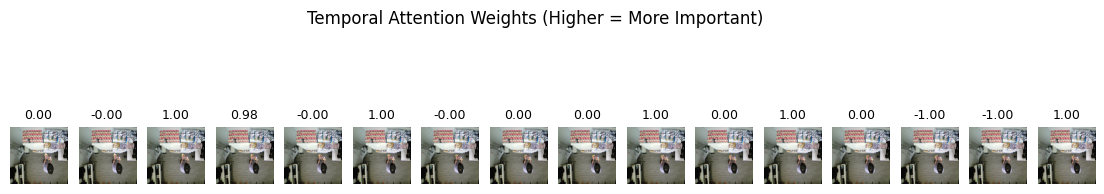

In [ ]:
video_id, _, start = sequence_index[100]
visualize_attention(video_id, start)

In [ ]:
grad_model = Model(
    inputs=cnn.input,
    outputs=[cnn.get_layer("Conv_1").output, cnn.output]
)

In [ ]:
def compute_gradcam(frame):
    frame = np.expand_dims(frame / 255.0, axis=0)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(frame)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]

    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [ ]:
def show_gradcam(frame):
    heatmap = compute_gradcam(frame)
    heatmap = cv2.resize(heatmap, IMG_SIZE)

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM (Spatial Attention)")
    plt.axis("off")
    plt.show()


In [ ]:
# Pick one frame from an attended sequence
cap = cv2.VideoCapture(f"{VIDEO_DIR}/{video_id}.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, start + SEQ_LEN // 2)
ret, frame = cap.read()
cap.release()

frame = cv2.resize(frame, IMG_SIZE)
show_gradcam(frame)


InvalidArgumentError: {{function_node __wrapped__Pack_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Shapes of all inputs must match: values[0].shape = [] != values[1].shape = [4,1280] [Op:Pack] name: 